In [1]:
import numpy as np
import matplotlib.pyplot as pyplot

In [2]:
x = [1, 3, 4.5, 5.5]
y = [2.5, 3, 3, 3.5]


In [3]:
X = np.array([[1. , 1. ],
       [1. , 3. ],
       [1. , 4.5],
       [1. , 5.5]])


In [4]:
y = np.array(y)
theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)


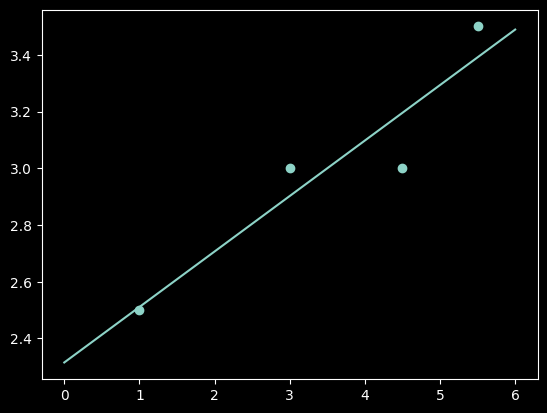

In [5]:
pyplot.scatter(x, y)
a = np.linspace(0, 6, 2)
b = theta[0] + a * theta[1]
pyplot.plot(a, b)


In [6]:
def gradient_step(theta, x, y, alpha, verbose=False):
    if verbose: print("Gradient step ", theta, x, y, alpha)
    delta = np.zeros(np.shape(theta))
    m = len(y)
    for i in range(m):
        delta[0] -= (2/float(m)) * (y[i] - h(theta, x[i]))
        delta[1] -= (2/float(m)) * (y[i] - h(theta, x[i])) * x[i]
        if verbose: print(i, delta)
    if verbose:
        print("Theta", theta - alpha * delta)
        print("Cost", sum(1/(2*m) * np.square(h(theta, np.array(x)) - np.array(y))))
    return theta - alpha * delta

def gradient_descent(x, y, initial_theta, alpha, iterations, verbose=False):
    theta = initial_theta
    for i in range(iterations):
        if verbose: print("** Iteration ", i)
        theta = gradient_step(theta, x, y, alpha, verbose)
    return theta


In [7]:
def h(theta, x):
    return theta[0] + theta[1] * x


In [8]:
def cost_2(theta, x, y):
    m = np.size(y)
    return sum(1/(2*m) * np.square(h2(theta, np.array(x)) - np.array(y)))

def h2(theta, x):
    X = np.ones([len(x),len(theta)])
    X[:,1] = x
    return X.dot(theta.T)

def linear_cost_prime(hyp, theta, x, y):
    m = np.size(y)
    delta = np.zeros(np.shape(theta))
    delta[0] -= (2/float(m)) * sum((y - hyp(theta, x)))
    delta[1] -= (2/float(m)) * sum((y - hyp(theta, x)) * x)
    return delta

def gradient_descent_2(hyp, cost, cost_prime, x, y, theta, alpha, iterations, verbose=False):
    cost_history = []
    delta = np.zeros(np.shape(theta))
    for i in range(iterations):
        if verbose: print("** Iteration ", i)
        delta = cost_prime(hyp, theta, x, y)
        theta = theta - alpha * delta
        cost_history.append(cost_2(theta, x, y))
    return theta, cost_history


In [9]:
theta2, cost_history = gradient_descent_2(h2, cost_2, linear_cost_prime, x, y, np.array([0, 0]), 0.05, 5000)

In [10]:
theta2

array([2.31521739, 0.19565217])

In [11]:
gradient_descent(x, y, np.array([1, 2]), 0.01, 2000)


array([2.31401837, 0.19593298])

In [12]:
theta

array([2.31521739, 0.19565217])